In [2]:
import json
from pathlib import Path

import h5py
import numpy as np

# --- deny-list of grid points with no spectrum --------------------------------
# species stores an all-zero spectrum for any grid point whose model file is
# absent and that linear interpolation could not recover. That is the
# "Could not interpolate N grid points so storing zeros instead" warning that
# add_model prints. Sampling one of those points gives a band flux of exactly
# 0.0, and get_magnitude then dies inside math.log10(0.0) with
# "math domain error". get_flux does not raise on them, it just hands back 0.0,
# so they quietly poison the flux columns as well.
#
# For Elf Owl every missing point sits at logg = 3.0: the distribution ships
# only 12 logg_3.00 spectra (all feh=1.0, co=0.458, logkzz=8.0) out of 1440,
# and logg=3.0 is on the edge of the axis so griddata could not extrapolate
# the rest. Nothing at logg >= 3.25 is missing.

DENY_PATH = Path("missing_grid_points.json")


def scan_missing_grid_points(tag, db_path="species_database.hdf5"):
    """Find every grid cell of `tag` that holds an all-zero spectrum.

    Returns (params, axes, mask), where `mask` is a boolean array over the grid
    axes that is True wherever the spectrum is missing.
    """
    with h5py.File(db_path, "r") as hdf:
        group = hdf[f"models/{tag}"]
        params = [group.attrs[f"parameter{i}"] for i in range(group.attrs["n_param"])]
        axes = {param: group[param][:] for param in params}

        flux = group["flux"]
        mask = np.zeros(flux.shape[: len(params)], dtype=bool)

        # One teff slice at a time (~68 MB) instead of the whole ~818 MB array.
        for i in range(flux.shape[0]):
            mask[i] = ~np.any(flux[i] != 0.0, axis=-1)

    return params, axes, mask


def denied_axis_values(params, axes, mask):
    """Smallest set of axis values to drop so no missing cell stays reachable.

    Greedy set cover: repeatedly drop whichever (parameter, value) accounts for
    the most still-missing cells. Because the sampler draws each axis
    independently, removing these values from the pool makes every possible
    draw valid by construction.
    """
    remaining = np.argwhere(mask)
    dropped = {}

    while len(remaining):
        best_axis, best_idx, best_count = None, None, -1

        for axis, param in enumerate(params):
            for idx in np.unique(remaining[:, axis]):
                count = int(np.count_nonzero(remaining[:, axis] == idx))
                if count > best_count:
                    best_axis, best_idx, best_count = axis, idx, count

        best_param = params[best_axis]
        dropped.setdefault(best_param, []).append(float(axes[best_param][best_idx]))
        remaining = remaining[remaining[:, best_axis] != best_idx]

    return dropped


def load_deny_list(tags, db_path="species_database.hdf5", path=DENY_PATH, rebuild=False):
    """Load the cached deny-list, scanning the database the first time."""
    if path.exists() and not rebuild:
        return json.loads(path.read_text())

    deny = {}

    for tag in tags:
        params, axes, mask = scan_missing_grid_points(tag, db_path)

        combos = [
            [float(axes[param][i]) for param, i in zip(params, idx)]
            for idx in np.argwhere(mask)
        ]

        deny[tag] = {
            "params": params,
            "denied_axis_values": denied_axis_values(params, axes, mask),
            "combos": combos,
        }

        print(
            f"{tag}: {len(combos)} missing grid points"
            f" -> drop {deny[tag]['denied_axis_values']}"
        )

    path.write_text(json.dumps(deny, indent=1))

    return deny


species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed
models loaded
sonora-elfowl-t: dropping logg = [np.float64(3.0)] (no spectra)
model array created
sonora-elfowl-y: dropping logg = [np.float64(3.0)] (no spectra)
model_y array created
flux models loaded
staring with planet 0 with parameters: {'teff': 650.0, 'logg': 4.5, 'feh': -0.5, 'c_o_ratio': 0.229, 'log_kzz': 9.0, 'radius': 1.1314981243496287, 'distance': 10.0}
planet magnitude found 0
staring with planet 1 with parameters: {'teff': 600.0, 'logg': 4.0, 'feh': 1.0, 'c_o_ratio': 0.687, 'log_kzz': 9.0, 'radius': 0.7630555603969764, 'distance': 10.0}
planet m

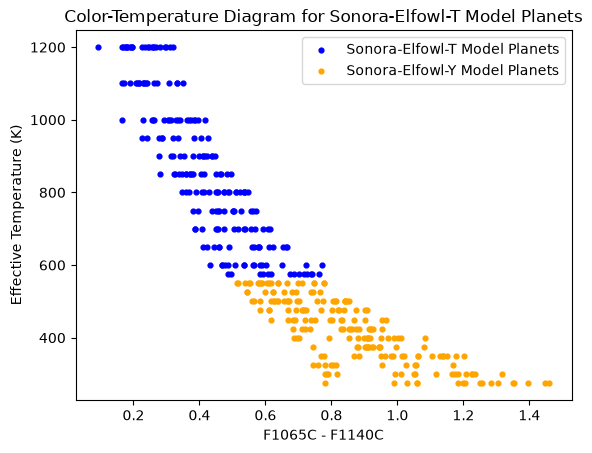

In [ ]:
from contextlib import contextmanager
from itertools import product

import numpy as np
from species import SpeciesInit
from species.data.database import Database
from species.read.read_model import ReadModel
import species.read.read_model as read_model_module
import matplotlib.pyplot as plt

SpeciesInit()

db = Database()

#db.add_model('sonora-elfowl-t', wavel_range=(.61, 14.9), wavel_sampling=2000.0)
#db.add_model('sonora-elfowl-y', wavel_range=(.61, 14.9), wavel_sampling=2000.0)
# db.add_filter('JWST/MIRI.F1065C')
# db.add_filter('JWST/MIRI.F1140C')
# db.add_filter('JWST/MIRI.F1550C')

model = ReadModel('sonora-elfowl-t', wavel_range=(.61, 14.9))
model_y = ReadModel('sonora-elfowl-y', wavel_range=(.61, 14.9))

print('models loaded')

# grid points that have no spectrum behind them, see the cell above
deny = load_deny_list(['sonora-elfowl-t', 'sonora-elfowl-y'])


@contextmanager
def skip_nearest_spec_check():
    """Turn off species' per-call missing-spectrum check inside this block.

    This is what made each magnitude take about a minute. ReadModel.get_model
    calls check_nearest_spec on every single call, and that helper builds a
    fresh ReadModel and calls get_data once per corner of the 5-D grid cell, so
    2**5 = 32 times. get_data does

        flux = np.array(hdf5_file[f"models/{self.model}/flux"])
        flux = flux[..., self.wl_index]

    i.e. it reads the whole ~818 MB flux dataset off disk and only then keeps
    the filter's handful of channels. So one get_flux or get_magnitude costs
    about 26 GB of I/O, and one planet costs four of those.

    Measured on this grid: 10.7 s per call with the check, 0.0026 s without,
    and the returned flux and magnitude are bit-identical. All the check does
    is warn that a nearest grid point has no spectrum, which the deny-list
    above already guarantees cannot happen for the points we sample, so there
    is nothing for it to find. That warning is also the only thing it emits, so
    this silences the noise as a side effect.
    """
    original = read_model_module.check_nearest_spec
    read_model_module.check_nearest_spec = lambda *args, **kwargs: None
    try:
        yield
    finally:
        read_model_module.check_nearest_spec = original


def generate_planet_arrays(model: ReadModel, radius_range, distance=10, num_samples=200, deny=None):
    model_bounds = model.get_bounds()
    model_points = model.get_points()

    # Strip the values with no spectrum out of the pool before sampling, so
    # every draw is valid by construction. This throws away the handful of real
    # spectra that happen to share a denied value (Elf Owl ships 12 logg=3.00
    # files), but reaching one needs three other parameters to coincide as
    # well, so independent per-axis sampling would essentially never hit them.
    model_deny = (deny or {}).get(model.model, {})
    denied = model_deny.get('denied_axis_values', {})
    pool = {}
    for key in model_bounds.keys():
        values = model_points[key]
        keep = values[~np.isin(values, denied.get(key, []))]
        if len(keep) < len(values):
            print(f"{model.model}: dropping {key} = {sorted(set(values) - set(keep))} (no spectra)")
        pool[key] = keep

    # nothing denied should still be reachable from the filtered pool
    denied_combos = {tuple(combo) for combo in model_deny.get('combos', [])}
    if denied_combos:
        params = model_deny['params']
        reachable = product(*(pool[param] for param in params))
        assert not any(tuple(float(v) for v in combo) in denied_combos for combo in reachable), \
            "deny-list does not cover the whole sampling pool"

    random_values = {key: np.random.choice(vals, size=num_samples) for key, vals in pool.items()}
    #random_values = {key: np.random.uniform(low=val[0], high=val[1], size=num_samples) for key, val in model_bounds.items()}
    random_values['radius'] = np.random.uniform(low=radius_range[0], high=radius_range[1], size=num_samples)
    random_values['distance'] = np.full(num_samples, distance)
    return random_values

def iter_planets(planet_arrays):
      n = len(next(iter(planet_arrays.values())))
      for i in range(n):
          yield {key: float(val[i]) for key, val in planet_arrays.items()}

def flux_and_abs_mag(reader: ReadModel, planet):
    # get_flux returns (flux, uncertainty) and the uncertainty is always None
    band_flux = reader.get_flux(planet)[0]

    if not np.isfinite(band_flux) or band_flux <= 0.0:
        # a missing spectrum stored as zeros, get_magnitude would raise
        # "math domain error" out of log10, so leave a gap instead
        return np.nan, np.nan

    # get_magnitude returns (apparent, absolute)
    return band_flux, reader.get_magnitude(planet)[1]

def update_planet_flux_and_magnitude(model: ReadModel, planet_arrays):
    flux_model_1065 = ReadModel(model.model, wavel_range=(.61, 14.9), filter_name="JWST/MIRI.F1065C")
    flux_model_1140 = ReadModel(model.model, wavel_range=(.61, 14.9), filter_name="JWST/MIRI.F1140C")
    print('flux models loaded')
    # unable to get this value to do model constraints
    #flux_model_1550 = ReadModel(model.model, wavel_range=(.61, 14.9), filter_name="JWST/MIRI.F1550C")

    flux_1065, flux_1140 = [], []
    abs_mag_1065, abs_mag_1140 = [], []

    with skip_nearest_spec_check():
        planet_count = 0
        # get_flux/get_magnitude take one planet at a time, so walk the rows
        for planet in iter_planets(planet_arrays):
            print('staring with planet', planet_count, 'with parameters:', planet)
            planet_flux_1065, planet_mag_1065 = flux_and_abs_mag(flux_model_1065, planet)
            planet_flux_1140, planet_mag_1140 = flux_and_abs_mag(flux_model_1140, planet)
            # unable to get this value to do model constraints
            #flux_1550.append(flux_model_1550.get_flux(planet)[0])

            flux_1065.append(planet_flux_1065)
            flux_1140.append(planet_flux_1140)
            abs_mag_1065.append(planet_mag_1065)
            abs_mag_1140.append(planet_mag_1140)
            print("planet magnitude found", planet_count)
            planet_count += 1

    out = dict(planet_arrays)
    out['flux_1065C'] = np.array(flux_1065)
    out['flux_1140C'] = np.array(flux_1140)
    # unable to get this value to do model constraints
    #out['flux_1550C'] = np.array(flux_1550)
    out['abs_mag_1065'] = np.array(abs_mag_1065)
    out['abs_mag_1140'] = np.array(abs_mag_1140)

    out['F1065C - F1140C'] = out['abs_mag_1065'] - out['abs_mag_1140']

    dropped = int(np.count_nonzero(np.isnan(out['F1065C - F1140C'])))
    if dropped:
        print(f"{model.model}: {dropped} planets had no usable spectrum and are plotted as gaps")

    return out

model_planet_array = generate_planet_arrays(model, radius_range=(0.6, 1.3), distance=10, num_samples=200, deny=deny)
print('model array created')
model_y_planet_array = generate_planet_arrays(model_y, radius_range=(0.6, 1.3), distance=10, num_samples=200, deny=deny)
print('model_y array created')
#using np arrays, use the update_planet_flux_and_magnitude function to add flux and magnitude values to the model_planet_array
model_planet_array_with_flux = update_planet_flux_and_magnitude(model, model_planet_array)
model_y_planet_array_with_flux = update_planet_flux_and_magnitude(model_y, model_y_planet_array)
fig, ax = plt.subplots()

ax.scatter(model_planet_array_with_flux['F1065C - F1140C'], model_planet_array_with_flux['teff'],
           s=12, label='Sonora-Elfowl-T Model Planets', color="blue")
ax.scatter(model_y_planet_array_with_flux['F1065C - F1140C'], model_y_planet_array_with_flux['teff'],
           s=12, label='Sonora-Elfowl-Y Model Planets', color='orange')
ax.set_xlabel('F1065C - F1140C')
ax.set_ylabel('Effective Temperature (K)')
ax.set_title('Color-Temperature Diagram for Sonora-Elfowl-T Model Planets')
ax.legend()
fig.savefig('color_temperature_diagram.png', dpi=300)
plt.show()
